In [5]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_moons

In [6]:
X, _ = make_moons(n_samples=300, noise=0.07, random_state=42)

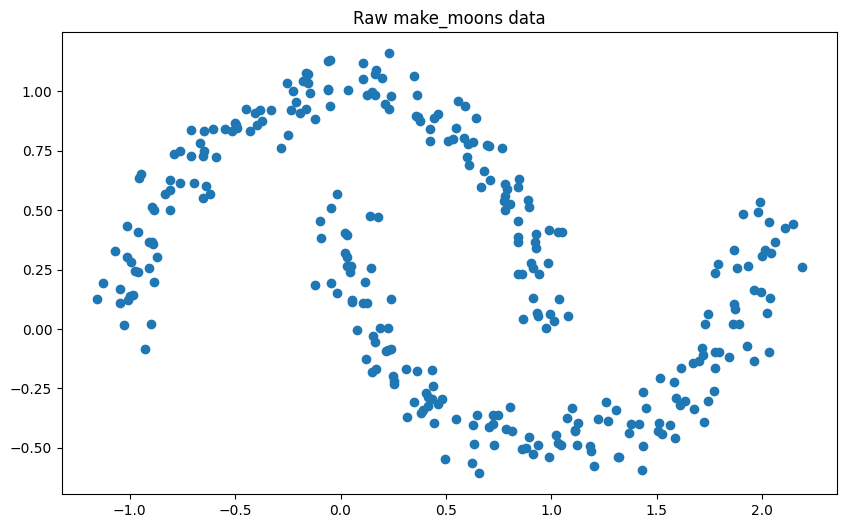

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.title('Raw make_moons data')
plt.show()

## It can be see how KMeans is performing badly

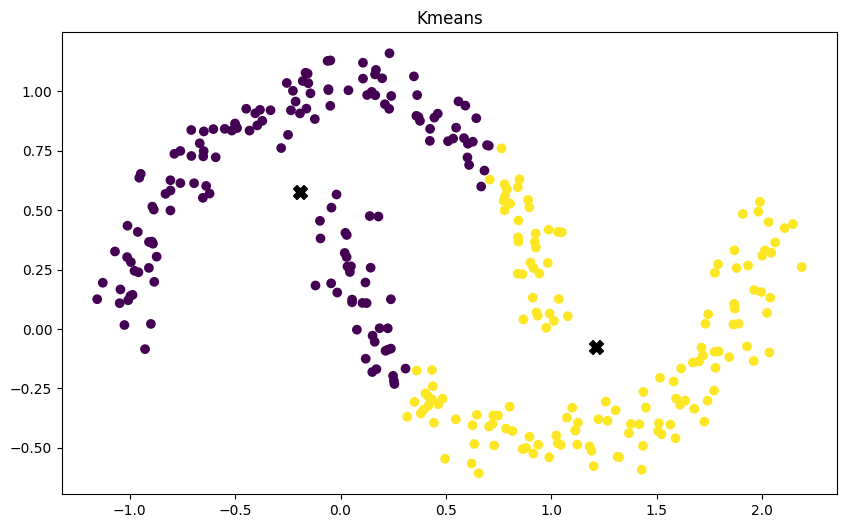

In [37]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
labels_km = kmeans.fit_predict(X)
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_km)
plt.title('Kmeans')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', s=100, marker='X')
plt.show()

## One the other hadn, DBSCAN nailed it

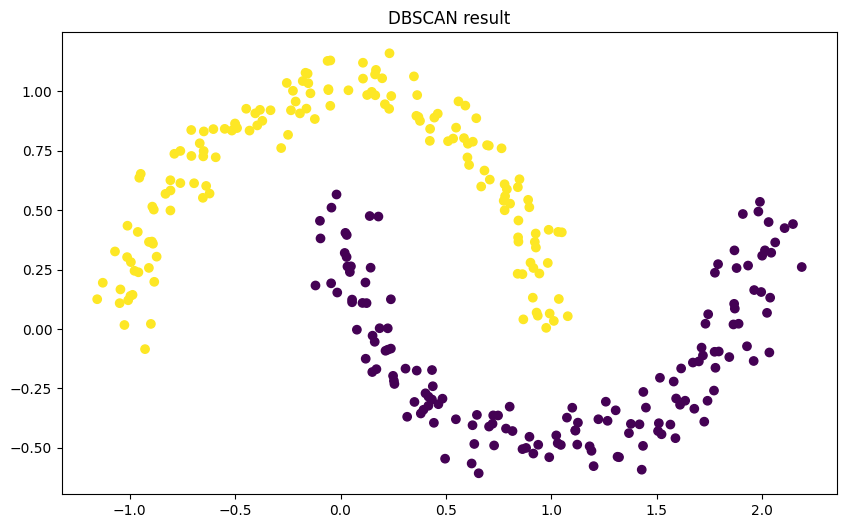

In [18]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.2, min_samples=5)

labels_dbscan = dbscan.fit_predict(X)
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_dbscan)
plt.title('DBSCAN result')
plt.show()

In [24]:
# printing all the unique values in our labels array, no duplicates
print(np.unique(labels_dbscan))

[0 1]


## Changing eps from 0.2 to 0.05, which resulted in the model performing worse as well as creaeting noise

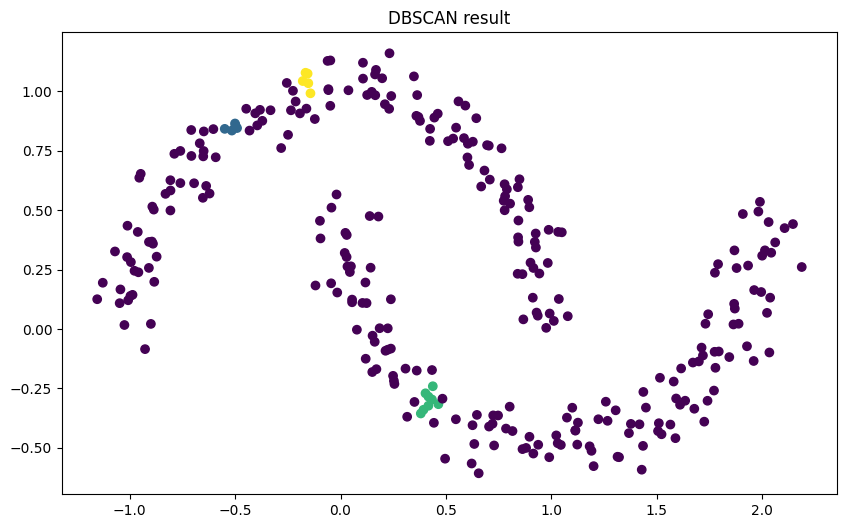

In [34]:
dbscan = DBSCAN(eps=0.05, min_samples=5)

labels_dbscan = dbscan.fit_predict(X)
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_dbscan)
plt.title('DBSCAN result')
plt.show()

In [26]:
print(np.unique(labels_dbscan))

[-1  0  1  2]


## Changing eps to 0.5, which is too high, did not also bring good results, making only one cluster

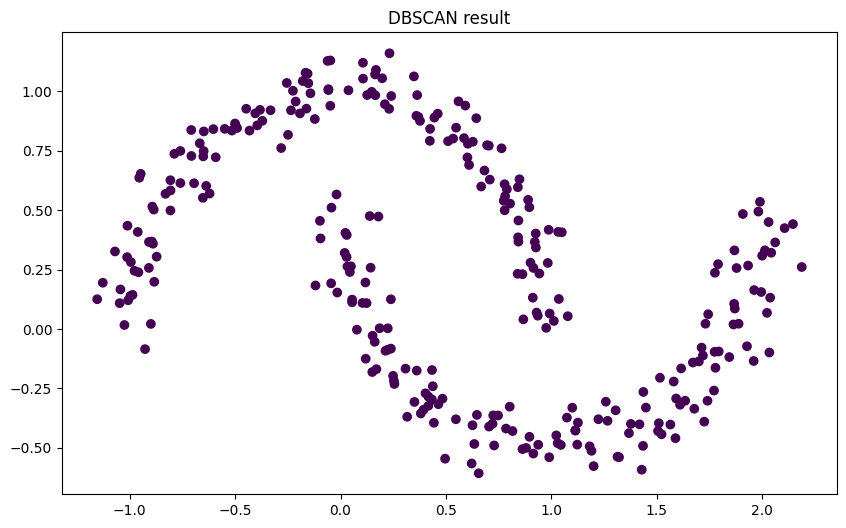

In [35]:
dbscan = DBSCAN(eps=0.5, min_samples=5)

labels_dbscan = dbscan.fit_predict(X)
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_dbscan)
plt.title('DBSCAN result')
plt.show()

In [36]:
print(np.unique(labels_dbscan))

[0]


## To conclude, it is clear that eps must be set to an almost perfect value so there's neither too few clusters nor too many, but the quantity we need. Additionally, min_samples also matters just as much as eps, but I only experimented on the values for eps.